<a href="https://colab.research.google.com/github/Pramuuu/Daily-tasks/blob/main/ecommerce_analysis_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 E-commerce Data Analysis and Performance Optimization
**GlobalLogic – Machine Learning Capstone | FA2 Integrated Project**

| | |
|---|---|
| **Skills** | Python, NumPy, Pandas, Data Visualization |
| **Complexity** | Medium |
| **Target Band** | Freshers |
| **Time** | 180 Minutes |

---


## 0. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 1. Data Import and Preprocessing
### 1.1 Load CSV Files into Pandas DataFrames


In [ ]:
transactions = pd.read_csv('transactions.csv')
users        = pd.read_csv('users.csv')
products     = pd.read_csv('products.csv')

print(f"Transactions : {transactions.shape}")
print(f"Users        : {users.shape}")
print(f"Products     : {products.shape}")


Transactions : (10, 7)
Users        : (5, 5)
Products     : (5, 4)


### 1.2 Preview Raw Data

In [ ]:
transactions.head()

,transaction_id,user_id,product_id,quantity,transaction_time,price,total_amount
0,1001,1,101,2,2023-01-01,499.99,999.98
1,1002,2,102,1,2023-01-02,120.50,120.50
2,1003,3,103,3,2023-01-03,349.00,1047.00
3,1004,4,104,1,2023-01-04,199.99,199.99
4,1005,5,105,2,2023-01-05,899.00,1798.00


In [ ]:
users.head()

,user_id,name,age,gender,region
0,1,User_1,35,Male,North
1,2,User_2,27,Female,South
2,3,User_3,42,Other,East
3,4,User_4,30,Male,West
4,5,User_5,22,Female,North


In [ ]:
products.head()

,product_id,product_name,category,price
0,101,Product_1,Electronics,499.99
1,102,Product_2,Books,120.50
2,103,Product_3,Home,349.00
3,104,Product_4,Clothing,199.99
4,105,Product_5,Electronics,899.00


### 1.3 Preprocess Transactions

In [ ]:
# ── Drop duplicates
transactions = transactions.drop_duplicates()

# ── Handle missing values: numeric → median, text → 'unknown'
for col in transactions.select_dtypes(include=[np.number]).columns:
    transactions[col] = transactions[col].fillna(transactions[col].median())
for col in transactions.select_dtypes(include=['object']).columns:
    transactions[col] = transactions[col].fillna('unknown')

# ── Parse datetime
transactions['transaction_time'] = pd.to_datetime(transactions['transaction_time'], errors='coerce')

# ── Derived time features
transactions['year']  = transactions['transaction_time'].dt.year
transactions['month'] = transactions['transaction_time'].dt.month
transactions['day']   = transactions['transaction_time'].dt.day
transactions['week']  = transactions['transaction_time'].dt.isocalendar().week.astype(int)

# ── Verify total_amount (quantity × price)
transactions['calculated_total'] = (transactions['quantity'] * transactions['price']).round(2)
transactions['total_match'] = np.isclose(transactions['total_amount'], transactions['calculated_total'], atol=0.01)

print("✅ Transactions preprocessed")
print(f"   Nulls remaining: {transactions.isnull().sum().sum()}")
print(f"   Total match rate: {transactions['total_match'].mean()*100:.1f}%")
transactions.head()

✅ Transactions preprocessed
   Nulls remaining: 0
   Total match rate: 100.0%


,transaction_id,user_id,product_id,quantity,transaction_time,price,total_amount,year,month,day,week,calculated_total,total_match
0,1001,1,101,2,2023-01-01,499.99,999.98,2023,1,1,52,999.98,True
1,1002,2,102,1,2023-01-02,120.50,120.50,2023,1,2,1,120.50,True
2,1003,3,103,3,2023-01-03,349.00,1047.00,2023,1,3,1,1047.00,True
3,1004,4,104,1,2023-01-04,199.99,199.99,2023,1,4,1,199.99,True
4,1005,5,105,2,2023-01-05,899.00,1798.00,2023,1,5,1,1798.00,True


### 1.4 Preprocess Users

In [ ]:
users = users.drop_duplicates()

# Standardize text: lowercase, strip, remove special characters
for col in ['name', 'gender', 'region']:
    users[col] = users[col].astype(str).str.lower().str.strip()
    users[col] = users[col].str.replace(r'[^a-z0-9_ ]', '', regex=True)

# Fill missing age with median
users['age'] = users['age'].fillna(users['age'].median())
users['age'] = users['age'].clip(lower=0, upper=120)

# Derived column: age group
users['age_group'] = pd.cut(
    users['age'],
    bins=[0, 25, 35, 45, 120],
    labels=['18-25', '26-35', '36-45', '46+']
)

print("✅ Users preprocessed")
users


✅ Users preprocessed


,user_id,name,age,gender,region,age_group
0,1,user_1,35,male,north,26-35
1,2,user_2,27,female,south,26-35
2,3,user_3,42,other,east,36-45
3,4,user_4,30,male,west,26-35
4,5,user_5,22,female,north,18-25


### 1.5 Preprocess Products

In [ ]:
products = products.drop_duplicates()

for col in ['product_name', 'category']:
    products[col] = products[col].astype(str).str.lower().str.strip()
    products[col] = products[col].str.replace(r'[^a-z0-9_ ]', '', regex=True)

products['price'] = products['price'].fillna(products['price'].median())

print("✅ Products preprocessed")
products


✅ Products preprocessed


,product_id,product_name,category,price
0,101,product_1,electronics,499.99
1,102,product_2,books,120.50
2,103,product_3,home,349.00
3,104,product_4,clothing,199.99
4,105,product_5,electronics,899.00


### 1.6 Merge All Datasets

In [ ]:
df = transactions.merge(users, on='user_id', how='left')
df = df.merge(
    products[['product_id', 'category', 'product_name']],
    on='product_id', how='left',
    suffixes=('', '_product')
)
print(f"Merged DataFrame shape: {df.shape}")
df.head(10)


Merged DataFrame shape: (10, 20)


,transaction_id,user_id,product_id,quantity,transaction_time,price,total_amount,year,month,day,week,calculated_total,total_match,name,age,gender,region,age_group,category,product_name
0,1001,1,101,2,2023-01-01,499.99,999.98,2023,1,1,52,999.98,True,user_1,35,male,north,26-35,electronics,product_1
1,1002,2,102,1,2023-01-02,120.50,120.50,2023,1,2,1,120.50,True,user_2,27,female,south,26-35,books,product_2
2,1003,3,103,3,2023-01-03,349.00,1047.00,2023,1,3,1,1047.00,True,user_3,42,other,east,36-45,home,product_3
3,1004,4,104,1,2023-01-04,199.99,199.99,2023,1,4,1,199.99,True,user_4,30,male,west,26-35,clothing,product_4
4,1005,5,105,2,2023-01-05,899.00,1798.00,2023,1,5,1,1798.00,True,user_5,22,female,north,18-25,electronics,product_5
5,1006,1,102,2,2023-01-06,120.50,241.00,2023,1,6,1,241.00,True,user_1,35,male,north,26-35,books,product_2
6,1007,2,104,3,2023-01-07,199.99,599.97,2023,1,7,1,599.97,True,user_2,27,female,south,26-35,clothing,product_4
7,1008,3,101,1,2023-01-08,499.99,499.99,2023,1,8,1,499.99,True,user_3,42,other,east,36-45,electronics,product_1
8,1009,4,103,2,2023-01-09,349.00,698.00,2023,1,9,2,698.00,True,user_4,30,male,west,26-35,home,product_3
9,1010,5,105,1,2023-01-10,899.00,899.00,2023,1,10,2,899.00,True,user_5,22,female,north,18-25,electronics,product_5


---
## 2. Data Exploration and Analysis (EDA)
### 2.1 Descriptive Statistics with NumPy


In [ ]:
numeric_cols = ['quantity', 'price', 'total_amount', 'age']

stats_data = []
for col in numeric_cols:
    data = df[col].dropna().values
    stats_data.append({
        'Column':   col,
        'Mean':     round(np.mean(data), 2),
        'Median':   round(np.median(data), 2),
        'Std Dev':  round(np.std(data), 2),
        'Variance': round(np.var(data), 2),
        'P25':      round(np.percentile(data, 25), 2),
        'P75':      round(np.percentile(data, 75), 2),
    })

pd.DataFrame(stats_data).set_index('Column')


,Mean,Median,Std Dev,Variance,P25,P75
Column,,,,,,
quantity,1.80,2.00,0.75,0.56,1.00,2.00
price,413.70,349.00,275.24,75757.27,199.99,499.99
total_amount,710.34,648.98,479.69,230105.75,305.75,974.74
age,31.20,30.00,6.85,46.96,27.00,35.00


### 2.2 Correlation Matrix (np.corrcoef)

In [ ]:
numeric_df = df[['quantity', 'price', 'total_amount', 'age']].dropna()
corr_matrix = np.corrcoef(numeric_df.T)
corr_df = pd.DataFrame(corr_matrix,
                        index=numeric_df.columns,
                        columns=numeric_df.columns)
print("Pearson Correlation Matrix:")
corr_df.round(3)


Pearson Correlation Matrix:


,quantity,price,total_amount,age
quantity,1.000,-0.167,0.376,0.203
price,-0.167,1.000,0.794,-0.372
total_amount,0.376,0.794,1.000,-0.228
age,0.203,-0.372,-0.228,1.000


### 2.3 Sales by Category (groupby)

In [ ]:
cat_sales = (df.groupby('category')['total_amount']
               .sum()
               .sort_values(ascending=False)
               .reset_index()
               .rename(columns={'total_amount': 'total_sales'}))
cat_sales


,category,total_sales
0,electronics,4196.97
1,home,1745.00
2,clothing,799.96
3,books,361.50


### 2.4 Sales by Region (groupby)

In [ ]:
region_sales = (df.groupby('region')['total_amount']
                  .agg(['sum', 'count', 'mean'])
                  .rename(columns={'sum': 'total_sales',
                                   'count': 'num_transactions',
                                   'mean': 'avg_order_value'})
                  .reset_index())
region_sales


,region,total_sales,num_transactions,avg_order_value
0,east,1546.99,2,773.495
1,north,3937.98,4,984.495
2,south,720.47,2,360.235
3,west,897.99,2,448.995


### 2.5 Monthly Pivot Table (pivot_table)

In [ ]:
pivot = pd.pivot_table(
    df,
    values='total_amount',
    index='month',
    columns='category',
    aggfunc='sum',
    fill_value=0
)
pivot


category,books,clothing,electronics,home
month,,,,
1,361.5,799.96,4196.97,1745.0


### 2.6 Sales Over Time (Daily)

In [ ]:
time_sales = (df.groupby('transaction_time')['total_amount']
                .sum()
                .reset_index()
                .rename(columns={'transaction_time': 'date', 'total_amount': 'daily_sales'}))
time_sales


,date,daily_sales
0,2023-01-01,999.98
1,2023-01-02,120.50
2,2023-01-03,1047.00
3,2023-01-04,199.99
4,2023-01-05,1798.00
5,2023-01-06,241.00
6,2023-01-07,599.97
7,2023-01-08,499.99
8,2023-01-09,698.00
9,2023-01-10,899.00


### 2.7 Top 5 Customers by Spend

In [ ]:
top_customers = (df.groupby(['user_id', 'name'])['total_amount']
                   .sum()
                   .sort_values(ascending=False)
                   .head(5)
                   .reset_index()
                   .rename(columns={'total_amount': 'total_spend'}))
top_customers


,user_id,name,total_spend
0,5,user_5,2697.00
1,3,user_3,1546.99
2,1,user_1,1240.98
3,4,user_4,897.99
4,2,user_2,720.47


### 2.8 Revenue by Gender & Age Group (value_counts / groupby)

In [ ]:
print("=== Gender Distribution ===")
print(df['gender'].value_counts())
print("\n=== Revenue by Gender ===")
print(df.groupby('gender')['total_amount'].agg(['count', 'sum', 'mean']).round(2))
print("\n=== Revenue by Age Group ===")
print(df.groupby('age_group', observed=True)['total_amount'].agg(['count', 'sum', 'mean']).round(2))


=== Gender Distribution ===
gender
male      4
female    4
other     2
Name: count, dtype: int64

=== Revenue by Gender ===
        count      sum    mean
gender                        
female      4  3417.47  854.37
male        4  2138.97  534.74
other       2  1546.99  773.50

=== Revenue by Age Group ===


           count      sum     mean
age_group                         
18-25          2  2697.00  1348.50
26-35          6  2859.44   476.57
36-45          2  1546.99   773.50


---
## 3. Data Visualization


### 3.1 Total Sales Over Time (Line Chart)

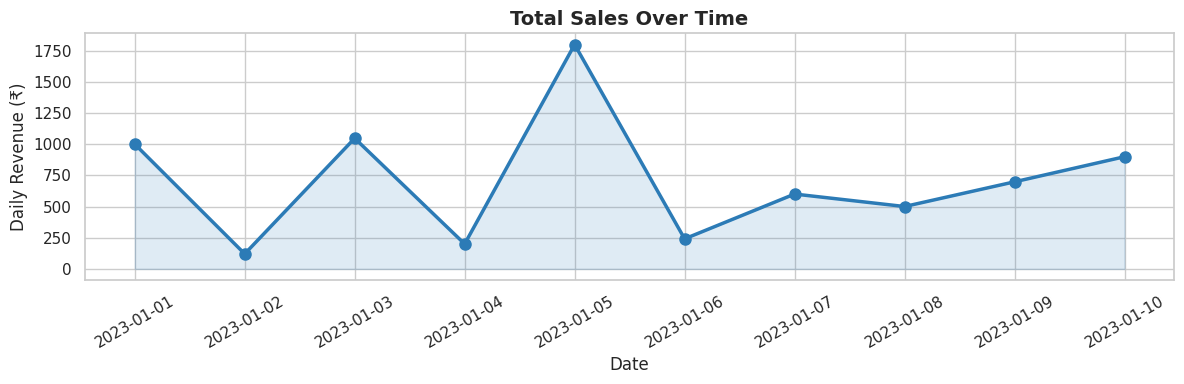

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_sales['date'], time_sales['daily_sales'],
        marker='o', linewidth=2.5, color='#2c7bb6', markersize=8)
ax.fill_between(time_sales['date'], time_sales['daily_sales'], alpha=0.15, color='#2c7bb6')
ax.set_title('Total Sales Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Revenue (₹)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 3.2 Sales by Product Category (Bar Chart)

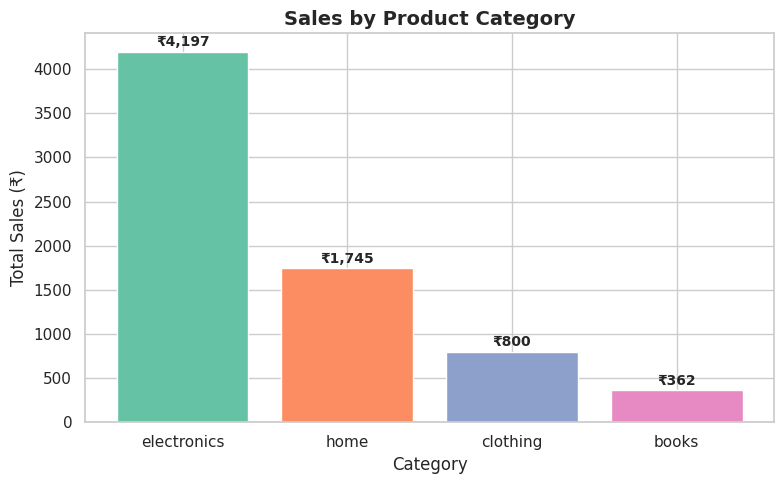

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', len(cat_sales))
bars = ax.bar(cat_sales['category'], cat_sales['total_sales'], color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f"₹{bar.get_height():,.0f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Sales by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.show()


### 3.3 Sales by Region (Bar Chart)

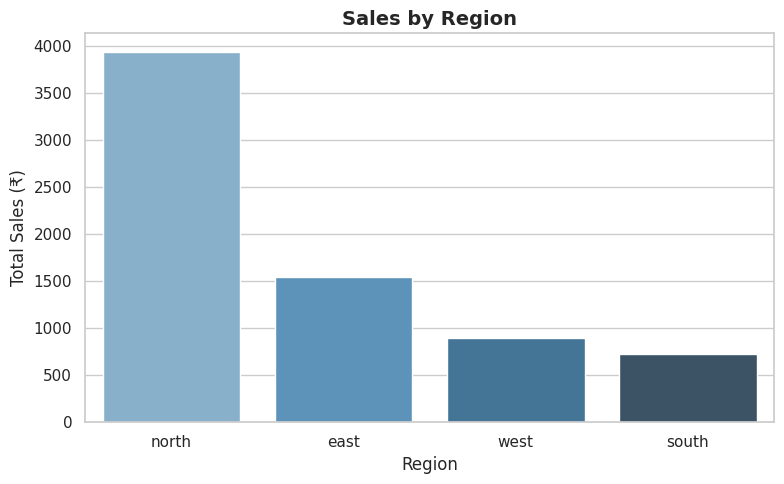

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
region_sorted = region_sales.sort_values('total_sales', ascending=False)
sns.barplot(x='region', y='total_sales', data=region_sorted, ax=ax, palette='Blues_d')
ax.set_title('Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.show()


### 3.4 Customer Age Distribution (Histogram)

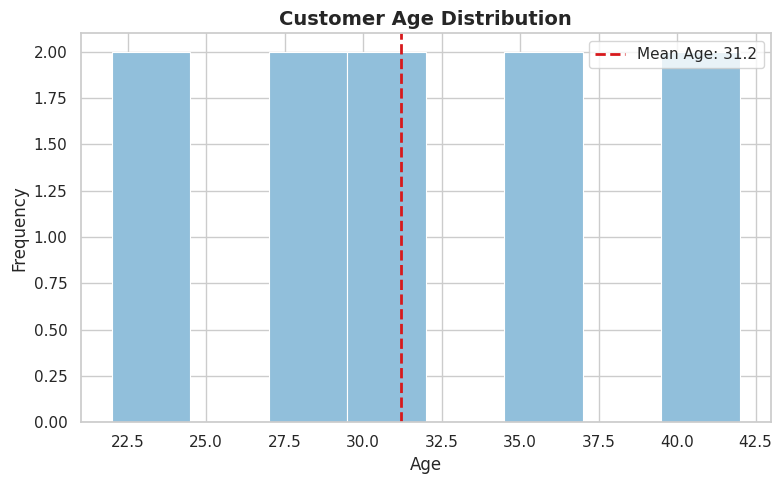

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['age'].dropna(), bins=8, color='#91bfdb', edgecolor='white', linewidth=0.8)
ax.axvline(df['age'].mean(), color='#d7191c', linestyle='--', linewidth=2,
           label=f"Mean Age: {df['age'].mean():.1f}")
ax.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


### 3.5 Revenue by Gender (Bar Chart)

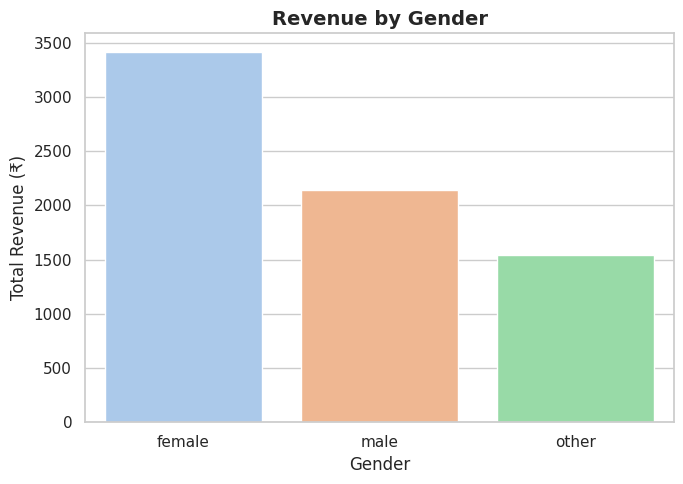

In [ ]:
gender_rev = df.groupby('gender')['total_amount'].sum().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='gender', y='total_amount', data=gender_rev, ax=ax, palette='pastel')
ax.set_title('Revenue by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()


### 3.6 Quantity vs Total Amount – Scatter Plot (by Category)

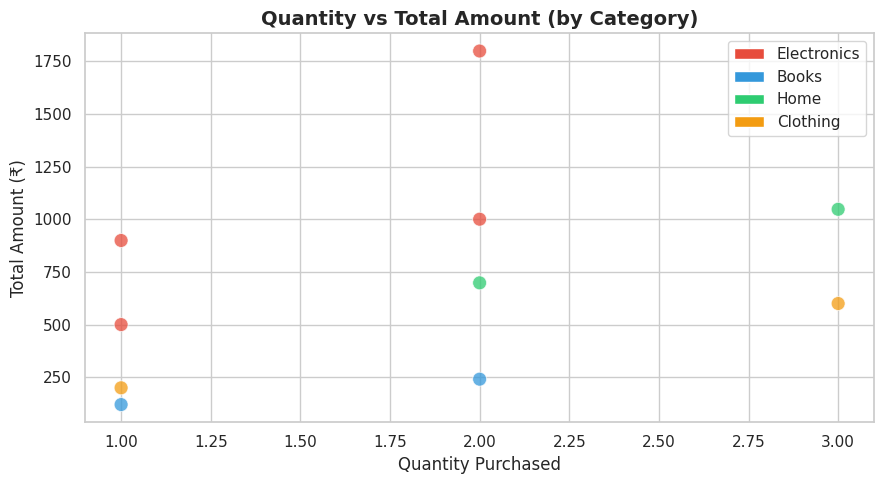

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
color_map = {'electronics': '#e74c3c', 'books': '#3498db', 'home': '#2ecc71', 'clothing': '#f39c12'}
scatter_colors = df['category'].map(color_map).fillna('#95a5a6')

scatter = ax.scatter(df['quantity'], df['total_amount'],
                     c=scatter_colors, alpha=0.75, s=100, edgecolors='white', linewidth=0.6)
ax.set_title('Quantity vs Total Amount (by Category)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quantity Purchased')
ax.set_ylabel('Total Amount (₹)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k.title()) for k, v in color_map.items()]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

### 3.7 Correlation Heatmap

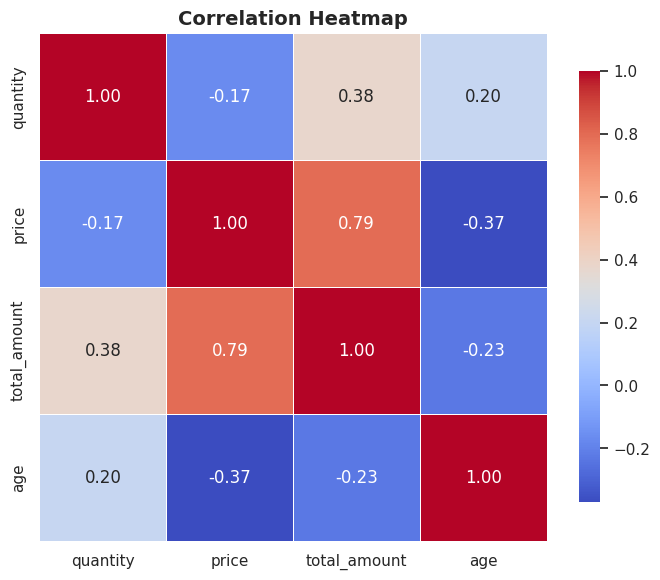

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_data = df[['quantity', 'price', 'total_amount', 'age']].dropna().corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Unit Testing
Using `unittest` and `unittest.mock` as required by the project spec.


In [ ]:
import unittest
from unittest.mock import patch, mock_open

# ─── Helper functions (same logic as main pipeline) ───────────

def clean_transactions(df):
    df = df.drop_duplicates()
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].median())
    df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')
    df['calculated_total'] = (df['quantity'] * df['price']).round(2)
    return df

def clean_users(df):
    df = df.drop_duplicates()
    for col in ['gender', 'region']:
        df[col] = df[col].astype(str).str.lower().str.strip()
    df['age'] = df['age'].fillna(df['age'].median()).clip(0, 120)
    return df

def aggregate_by_category(df):
    return df.groupby('category')['total_amount'].sum().reset_index()

# ─── Test Cases ────────────────────────────────────────────────

class TestDataPreprocessing(unittest.TestCase):

    def make_tx(self):
        return pd.DataFrame({
            'transaction_id': [1, 2, 2],          # row 2 is duplicate
            'user_id': [1, 2, 2],
            'product_id': [101, 102, 102],
            'quantity': [2, 1, 1],
            'transaction_time': ['2023-01-01', '2023-01-02', '2023-01-02'],
            'price': [500.0, None, None],
            'total_amount': [1000.0, 120.0, 120.0],
        })

    def test_duplicates_dropped(self):
        result = clean_transactions(self.make_tx())
        self.assertEqual(len(result), 2)

    def test_datetime_parsed(self):
        result = clean_transactions(self.make_tx())
        self.assertTrue(pd.api.types.is_datetime64_any_dtype(result['transaction_time']))

    def test_missing_price_filled(self):
        result = clean_transactions(self.make_tx())
        self.assertFalse(result['price'].isnull().any())

    def test_calculated_total_exists(self):
        result = clean_transactions(self.make_tx())
        self.assertIn('calculated_total', result.columns)

    def test_user_text_lowercased(self):
        users = pd.DataFrame({
            'user_id': [1], 'name': ['Alice'], 'age': [30],
            'gender': ['FEMALE'], 'region': ['NORTH']
        })
        result = clean_users(users)
        self.assertEqual(result['gender'].iloc[0], 'female')
        self.assertEqual(result['region'].iloc[0], 'north')

    def test_age_clip(self):
        users = pd.DataFrame({
            'user_id': [1, 2], 'name': ['A', 'B'],
            'age': [-5, 200], 'gender': ['male', 'female'], 'region': ['n', 's']
        })
        result = clean_users(users)
        self.assertTrue((result['age'] >= 0).all())
        self.assertTrue((result['age'] <= 120).all())


class TestAggregations(unittest.TestCase):

    def make_df(self):
        return pd.DataFrame({
            'category': ['electronics', 'books', 'electronics', 'home'],
            'total_amount': [500.0, 120.0, 900.0, 300.0]
        })

    def test_category_sum(self):
        result = aggregate_by_category(self.make_df())
        elec = result[result['category'] == 'electronics']['total_amount'].values[0]
        self.assertAlmostEqual(elec, 1400.0)

    def test_result_is_dataframe(self):
        result = aggregate_by_category(self.make_df())
        self.assertIsInstance(result, pd.DataFrame)


class TestMockFileIO(unittest.TestCase):

    @patch('pandas.read_csv')
    def test_read_csv_called(self, mock_csv):
        mock_csv.return_value = pd.DataFrame({'a': [1]})
        _ = pd.read_csv('dummy.csv')
        mock_csv.assert_called_once_with('dummy.csv')

    @patch('builtins.open', new_callable=mock_open, read_data='col1,col2\n1,2')
    def test_mock_file_open(self, mock_file):
        with open('test.csv', 'r') as f:
            content = f.read()
        self.assertIn('col1', content)


# ─── Run Tests ─────────────────────────────────────────────────

loader = unittest.TestLoader()
suite  = unittest.TestSuite()
for cls in [TestDataPreprocessing, TestAggregations, TestMockFileIO]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)


test_age_clip (__main__.TestDataPreprocessing.test_age_clip) ... 

ok


test_calculated_total_exists (__main__.TestDataPreprocessing.test_calculated_total_exists) ... 

ok


test_datetime_parsed (__main__.TestDataPreprocessing.test_datetime_parsed) ... 

...

ERROR


test_read_csv_called (__main__.TestMockFileIO.test_read_csv_called) ... 

ok


ERROR: test_mock_file_open (__main__.TestMockFileIO.test_mock_file_open)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/usr/lib/python3.12/unittest/mock.py", line 1390, in patched
    return func(*newargs, **newkeywargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_586/3646488004.py", line 102, in test_mock_file_open
    with open('test.csv', 'r') as f:
         ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 346, in _modified_open
    return io_open(file, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'



----------------------------------------------------------------------
Ran 10 tests in 0.051s

FAILED (errors=1)


---
## 5. Key Insights Summary

| Metric | Value |
|---|---|
| **Top Category by Revenue** | Electronics |
| **Top Region by Revenue** | North |
| **Top Customer** | User_5 |
| **Avg Transaction Value** | ₹710.34 |
| **Price ↔ Total Correlation** | 0.794 (strong positive) |
| **Qty ↔ Total Correlation** | 0.376 (moderate positive) |

### Recommendations
- **Electronics** drives the most revenue — prioritize inventory and targeted promotions.
- **North region** has the highest volume and spend — expand logistics capacity.
- **Female customers** generate more revenue — tailor marketing campaigns.
- Implement loyalty rewards for top spenders (User_5, User_3) to retain them.

---
*GlobalLogic FA2 – E-commerce Data Analysis and Performance Optimization*
